# 13_Explainability

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, confusion_matrix,
    classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.manifold import TSNE

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

try:
    from Bio.SeqUtils.ProtParam import ProteinAnalysis
    HAS_BIOPYTHON = True
except ImportError:
    HAS_BIOPYTHON = False

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

In [18]:
# ===== 项目路径 =====
PROJECT_ROOT = Path.cwd().parent.parent  # 按你自己的 notebook 位置调整
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "interpretability"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ===== 数据文件路径（按实际情况修改）=====
# 1) 序列信息文件：至少包含 sequence 和 label 两列
TRAIN_META_PATH = PROCESSED_DIR / "prott5_residue" / "train_metadata.csv"
TEST_META_PATH  = PROCESSED_DIR / "prott5_residue" / "test_metadata.csv"

# 2) 最终用于模型预测的特征（handcrafted + prott5 + LGBM筛选后）
X_TRAIN_PATH = PROCESSED_DIR / "fusion_selected" / "fusion_selected" / "handcrafted_prott5_lgbm"
X_TEST_PATH  = PROCESSED_DIR / "fusion_selected" / "fusion_selected" / "handcrafted_prott5_lgbm"
Y_TRAIN_PATH = PROCESSED_DIR / "fusion_selected" / "fusion_selected" / "handcrafted_prott5_lgbm"
Y_TEST_PATH  = PROCESSED_DIR / "fusion_selected" / "fusion_selected" / "handcrafted_prott5_lgbm"

# 3) 特征名（强烈建议准备）
FEATURE_NAMES_PATH = PROCESSED_DIR / "fusion_selected" /"fusion_selected" / "selected_feature_names.csv"

# 4) 已训练好的 Bagging_DT 模型
MODEL_PATH = PROJECT_ROOT / "results" /"models" / "handcrafted_prott5_et.pkl"

In [19]:
# 数据读取
import joblib

# ---- 加载元数据（sequence, label）----
train_meta = pd.read_csv(TRAIN_META_PATH)
test_meta = pd.read_csv(TEST_META_PATH)


# 基本列检查
assert "sequence" in train_meta.columns, "train_meta.csv 必须包含 sequence 列"
assert "sequence" in test_meta.columns, "test_meta.csv 必须包含 sequence 列"

# label 如果没有，也可以从 y 文件中读
if "label" not in train_meta.columns:
    print("train_meta 中无 label 列，将使用 y_train.npy")
if "label" not in test_meta.columns:
    print("test_meta 中无 label 列，将使用 y_test.npy")

# ---- 加载特征 ----
X_train = np.load(X_TRAIN_PATH/ "X_train.npy")
X_test = np.load(X_TEST_PATH/ "X_test.npy")
y_train = np.load(Y_TRAIN_PATH/ "y_train.npy")
y_test = np.load(Y_TEST_PATH/ "y_test.npy")


# ---- 对齐 label ----
if "label" not in train_meta.columns:
    train_meta["label"] = y_train
if "label" not in test_meta.columns:
    test_meta["label"] = y_test

# ---- 加载特征名 ----
if FEATURE_NAMES_PATH.exists():
    feature_names = pd.read_csv(FEATURE_NAMES_PATH).iloc[:, 0].tolist()
else:
    feature_names = [f"feat_{i}" for i in range(X_train.shape[1])]
    print("未找到特征名文件，将使用默认 feat_0, feat_1, ...")

assert X_train.shape[1] == len(feature_names), "特征维度与 feature_names 数量不一致"

# ---- 加载模型 ----
model = joblib.load(MODEL_PATH)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Train meta   :", train_meta.shape)
print("Test meta    :", test_meta.shape)
print("Num features :", len(feature_names))
print("Model loaded :", type(model))

未找到特征名文件，将使用默认 feat_0, feat_1, ...
X_train shape: (3583, 1209)
X_test shape : (897, 1209)
Train meta   : (3583, 2)
Test meta    : (897, 2)
Num features : 1209
Model loaded : <class 'sklearn.ensemble._forest.ExtraTreesClassifier'>


## （1）基本指标

,ACC,Precision,Recall,F1,MCC,AUC
0,0.748049,0.723077,0.549708,0.624585,0.449603,0.819807


              precision    recall  f1-score   support

           0     0.7582    0.8703    0.8104       555
           1     0.7231    0.5497    0.6246       342

    accuracy                         0.7480       897
   macro avg     0.7407    0.7100    0.7175       897
weighted avg     0.7448    0.7480    0.7396       897



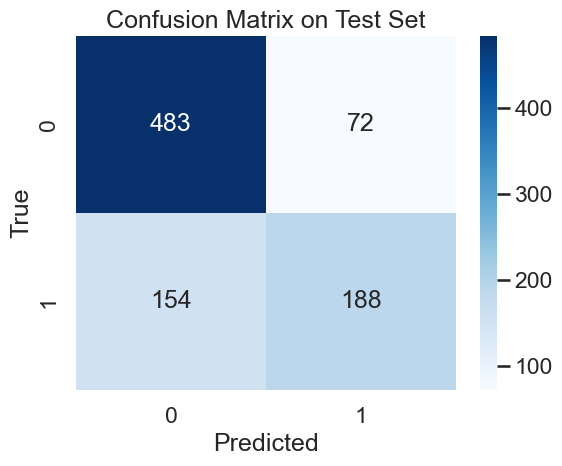

In [21]:
# 兼容部分模型没有 predict_proba 的情况
y_pred = model.predict(X_test)

if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_test)[:, 1]
else:
    y_prob = None

metrics_dict = {
    "ACC": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "MCC": matthews_corrcoef(y_test, y_pred),
}

if y_prob is not None:
    metrics_dict["AUC"] = roc_auc_score(y_test, y_prob)

metrics_df = pd.DataFrame([metrics_dict])
display(metrics_df)

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix on Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [22]:
test_df = test_meta.copy().reset_index(drop=True)
test_df["y_true"] = y_test
test_df["y_pred"] = y_pred
test_df["correct"] = (test_df["y_true"] == test_df["y_pred"]).astype(int)

if y_prob is not None:
    test_df["y_prob"] = y_prob

test_df["length"] = test_df["sequence"].astype(str).apply(len)

display(test_df.head())

,sequence,label,y_true,y_pred,correct,y_prob,length
0,KMQAMKLEKDNAMDR,1,1,1,1,0.643333,15
1,QDNSAKKEATPATPSKPTPS,1,1,1,1,0.616667,20
2,ADVVLIASIDHIT,1,1,1,1,0.766667,13
3,QKRAAYDQYGHAAFE,1,1,0,0,0.203333,15
4,GPTHLFQPSLVLDMAKVLLD,1,1,1,1,0.590000,20


## （2）氨基酸组成差异

In [6]:
AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")

def calc_aac(seq: str):
    seq = str(seq).upper()
    total = len(seq)
    counter = Counter(seq)
    if total == 0:
        return {aa: 0.0 for aa in AA_LIST}
    return {aa: counter.get(aa, 0) / total for aa in AA_LIST}

def build_aac_df(seqs):
    rows = []
    for seq in seqs:
        rows.append(calc_aac(seq))
    return pd.DataFrame(rows)

,Negative,Positive
A,0.082702,0.082895
C,0.012536,0.017585
D,0.060300,0.049617
E,0.065211,0.072227
F,0.044301,0.040208
G,0.071016,0.065271
H,0.020936,0.019035
I,0.054871,0.048311
K,0.071373,0.071506
L,0.079924,0.100304


,AA,mean_neg,mean_pos,diff_pos_minus_neg,p_value
9,L,0.079924,0.100304,0.020381,0.000575
14,R,0.039173,0.046209,0.007036,0.031858
3,E,0.065211,0.072227,0.007016,0.133300
1,C,0.012536,0.017585,0.005049,0.143272
13,Q,0.036369,0.040667,0.004299,0.343933
10,M,0.018980,0.021543,0.002563,0.485128
18,W,0.011504,0.012797,0.001292,0.394304
11,N,0.049990,0.051051,0.001061,0.989760
0,A,0.082702,0.082895,0.000193,0.625712
8,K,0.071373,0.071506,0.000133,0.601491


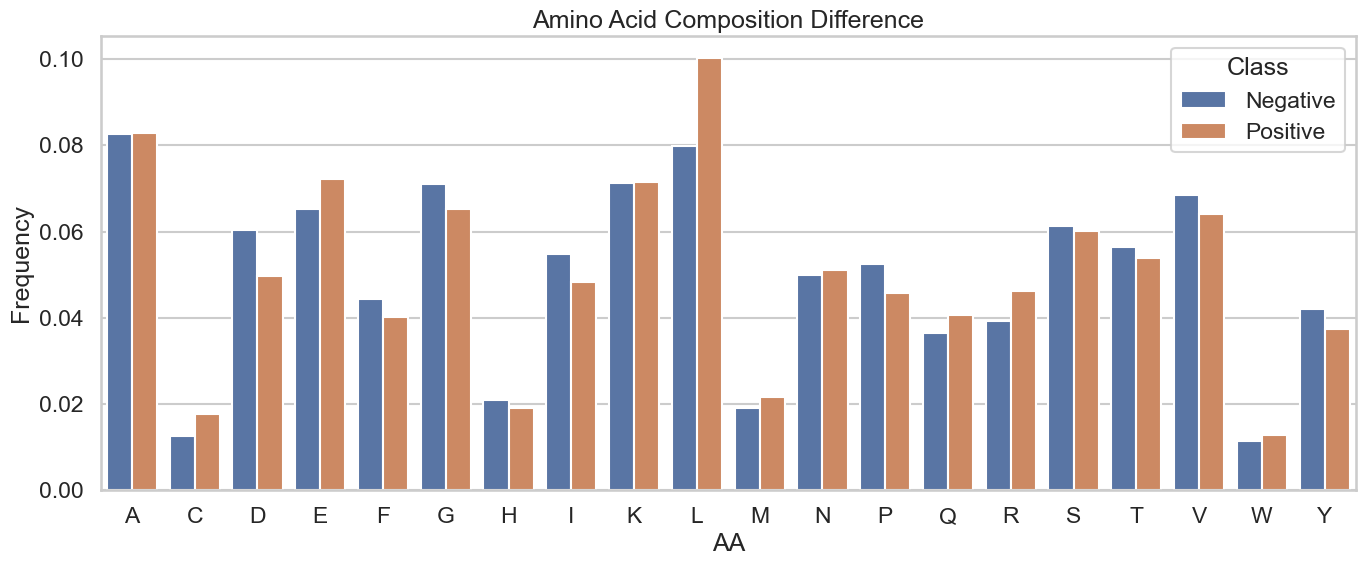

In [7]:
aac_df = build_aac_df(test_df["sequence"])
aac_df["label"] = test_df["y_true"].values

aac_mean = aac_df.groupby("label")[AA_LIST].mean().T
aac_mean.columns = ["Negative", "Positive"] if set(aac_mean.columns) == {0, 1} else aac_mean.columns

display(aac_mean)

# 统计检验
aac_stats = []
for aa in AA_LIST:
    group0 = aac_df.loc[aac_df["label"] == 0, aa]
    group1 = aac_df.loc[aac_df["label"] == 1, aa]
    stat, p = mannwhitneyu(group0, group1, alternative="two-sided")
    aac_stats.append({
        "AA": aa,
        "mean_neg": group0.mean(),
        "mean_pos": group1.mean(),
        "diff_pos_minus_neg": group1.mean() - group0.mean(),
        "p_value": p
    })

aac_stats_df = pd.DataFrame(aac_stats).sort_values("diff_pos_minus_neg", ascending=False)
display(aac_stats_df)

# 可视化
plot_df = aac_mean.reset_index().melt(id_vars="index", var_name="Class", value_name="Frequency")
plot_df = plot_df.rename(columns={"index": "AA"})

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x="AA", y="Frequency", hue="Class")
plt.title("Amino Acid Composition Difference")
plt.tight_layout()
plt.show()

aac_stats_df.to_csv(RESULTS_DIR / "aac_stats.csv", index=False)

## （3）长度分布差异

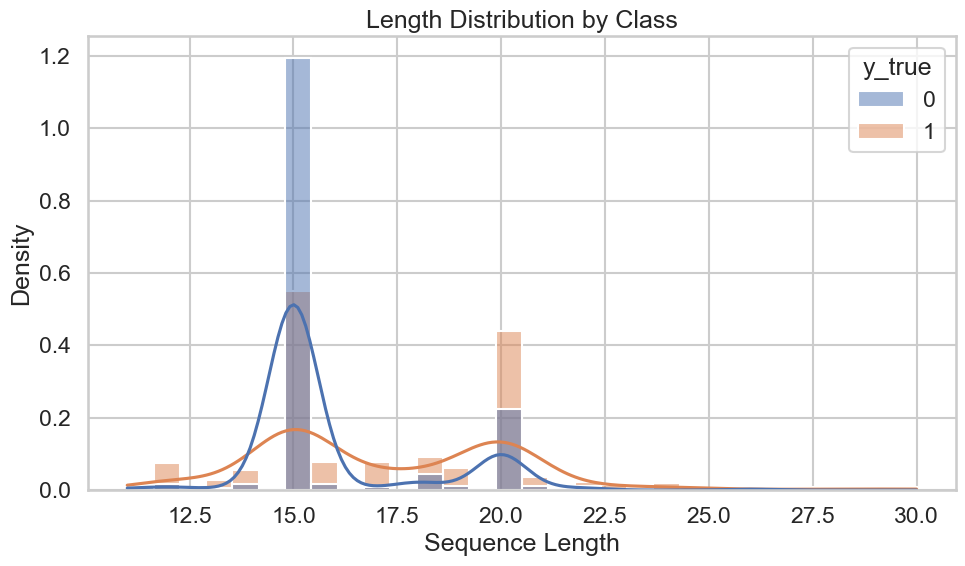

,mean_len_neg,mean_len_pos,median_len_neg,median_len_pos,p_value
0,NaN,NaN,NaN,NaN,NaN


In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(data=test_df, x="length", hue="y_true", bins=30, kde=True, stat="density", common_norm=False)
plt.title("Length Distribution by Class")
plt.xlabel("Sequence Length")
plt.tight_layout()
plt.show()

group0_len = test_df.loc[test_df["y_true"] == "Negtive", "length"]
group1_len = test_df.loc[test_df["y_true"] == "Positive", "length"]
stat, p = mannwhitneyu(group0_len, group1_len, alternative="two-sided")

length_summary = pd.DataFrame([{
    "mean_len_neg": group0_len.mean(),
    "mean_len_pos": group1_len.mean(),
    "median_len_neg": group0_len.median(),
    "median_len_pos": group1_len.median(),
    "p_value": p
}])
display(length_summary)

length_summary.to_csv(RESULTS_DIR / "length_summary.csv", index=False)

## （4）理化性质差异

In [25]:
if not HAS_BIOPYTHON:
    raise ImportError("请先安装 biopython: pip install biopython")

# Kyte-Doolittle 简单疏水性字典，可用于补充
KD_SCALE = {
    "A": 1.8, "C": 2.5, "D": -3.5, "E": -3.5, "F": 2.8,
    "G": -0.4, "H": -3.2, "I": 4.5, "K": -3.9, "L": 3.8,
    "M": 1.9, "N": -3.5, "P": -1.6, "Q": -3.5, "R": -4.5,
    "S": -0.8, "T": -0.7, "V": 4.2, "W": -0.9, "Y": -1.3
}

POS_AA = set(["K", "R", "H"])
NEG_AA = set(["D", "E"])

def calc_net_charge_simple(seq: str):
    seq = str(seq).upper()
    pos = sum(1 for x in seq if x in POS_AA)
    neg = sum(1 for x in seq if x in NEG_AA)
    return pos - neg

def calc_hydrophobic_ratio(seq: str):
    hydrophobic = set(["A", "V", "I", "L", "M", "F", "W", "Y", "C"])
    seq = str(seq).upper()
    if len(seq) == 0:
        return 0.0
    return sum(1 for x in seq if x in hydrophobic) / len(seq)

def calc_kd_mean(seq: str):
    seq = str(seq).upper()
    vals = [KD_SCALE[x] for x in seq if x in KD_SCALE]
    return np.mean(vals) if len(vals) > 0 else np.nan

def calc_physchem(seq: str):
    seq = str(seq).upper()
    pa = ProteinAnalysis(seq)
    return {
        "length": len(seq),
        "gravy": pa.gravy(),
        "aromaticity": pa.aromaticity(),
        "isoelectric_point": pa.isoelectric_point(),
        "instability_index": pa.instability_index(),
        "net_charge_simple": calc_net_charge_simple(seq),
        "hydrophobic_ratio": calc_hydrophobic_ratio(seq),
        "kd_mean": calc_kd_mean(seq),
    }

,length,gravy,aromaticity,isoelectric_point,instability_index,net_charge_simple,hydrophobic_ratio,kd_mean,label
0,15,-1.373333,0.00,8.497014,15.353333,1,0.400000,-1.373333,1
1,20,-1.560000,0.00,8.497658,44.250000,1,0.150000,-1.560000,1
2,13,1.353846,0.00,4.196787,36.500000,-1,0.615385,1.353846,1
3,15,-1.240000,0.20,6.765056,36.166667,1,0.466667,-1.240000,1
4,20,0.560000,0.05,5.391770,30.685000,0,0.500000,0.560000,1


,feature,mean_neg,mean_pos,median_neg,median_pos,diff_pos_minus_neg,p_value
0,length,15.909910,17.286550,15.000000,16.500000,1.376640,5.830777e-14
3,isoelectric_point,6.547625,6.758540,5.991080,6.068637,0.210915,1.424605e-01
5,net_charge_simple,0.072072,0.242690,0.000000,0.000000,0.170618,2.843965e-01
2,aromaticity,0.097950,0.090317,0.066667,0.066667,-0.007633,2.915766e-01
4,instability_index,33.800546,34.260754,29.353333,30.400000,0.460208,4.572794e-01
6,hydrophobic_ratio,0.415456,0.424941,0.400000,0.411765,0.009485,4.595020e-01
1,gravy,-0.350554,-0.326061,-0.373333,-0.391667,0.024494,6.220190e-01
7,kd_mean,-0.350554,-0.326061,-0.373333,-0.391667,0.024494,6.223940e-01


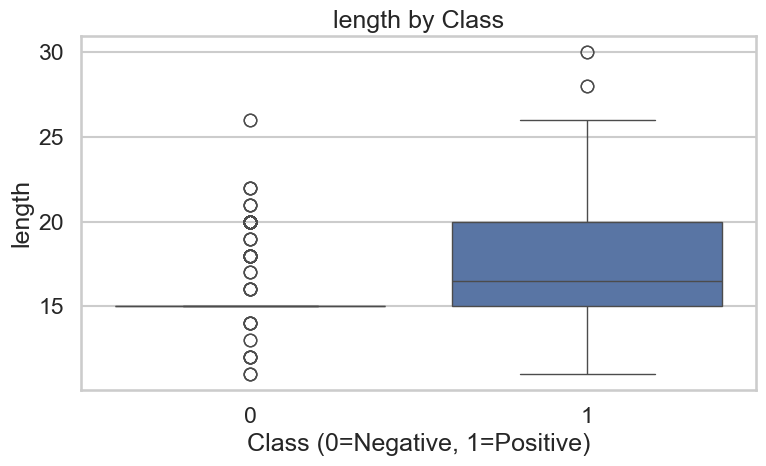

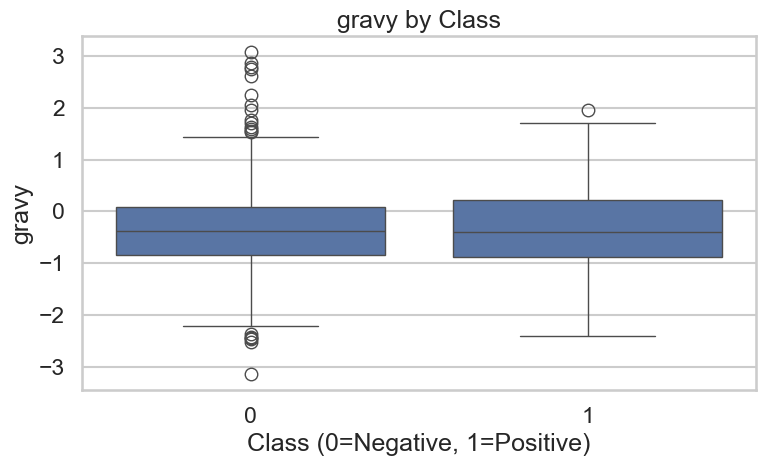

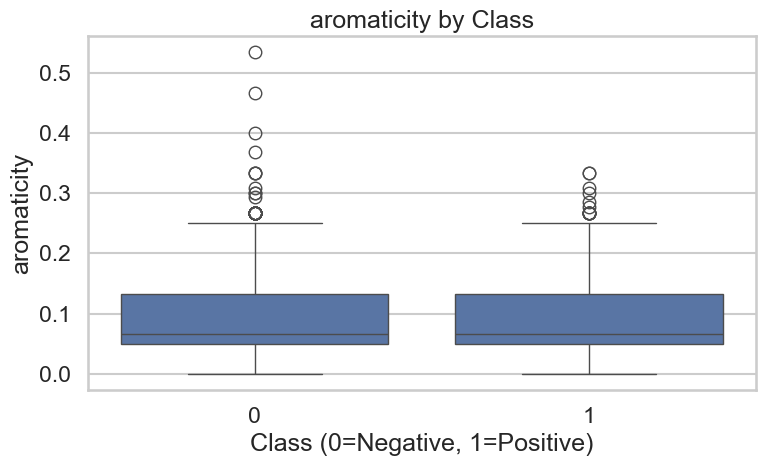

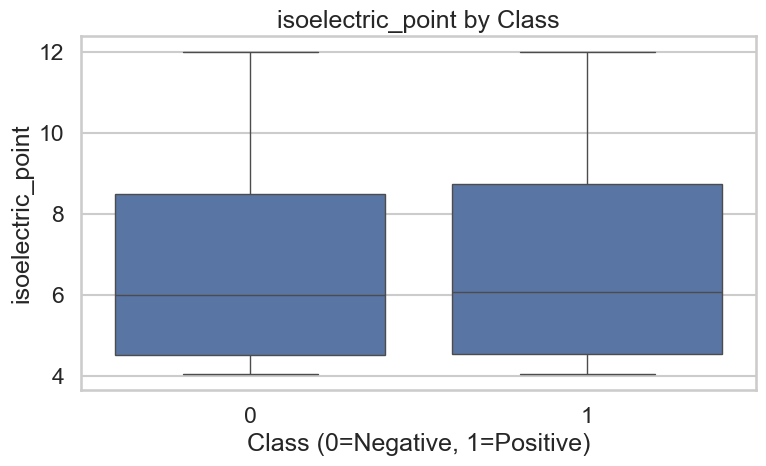

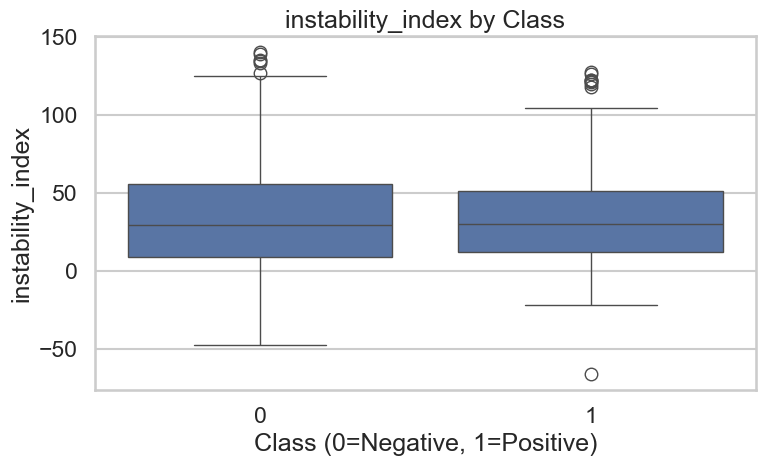

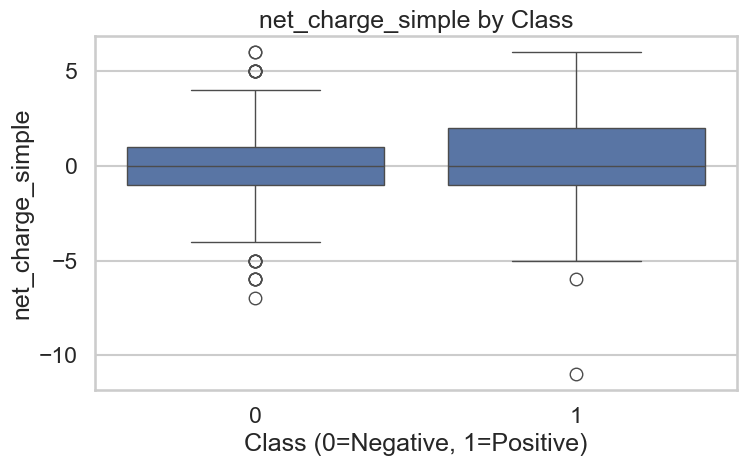

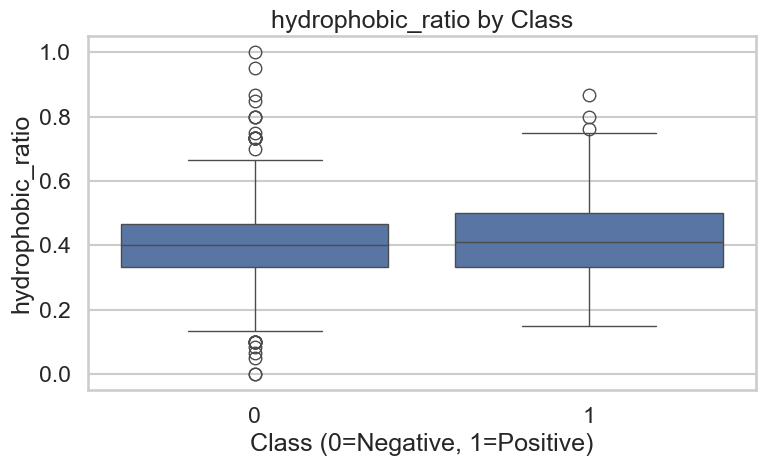

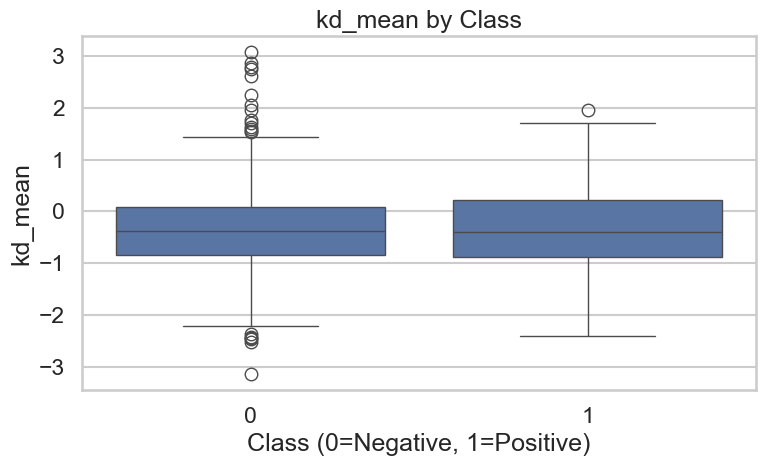

In [26]:
physchem_rows = [calc_physchem(seq) for seq in test_df["sequence"]]
physchem_df = pd.DataFrame(physchem_rows)
physchem_df["label"] = test_df["y_true"].values

display(physchem_df.head())

physchem_features = [
    "length", "gravy", "aromaticity", "isoelectric_point",
    "instability_index", "net_charge_simple", "hydrophobic_ratio", "kd_mean"
]

stats_rows = []
for feat in physchem_features:
    group0 = physchem_df.loc[physchem_df["label"] == 0, feat].dropna()
    group1 = physchem_df.loc[physchem_df["label"] == 1, feat].dropna()
    stat, p = mannwhitneyu(group0, group1, alternative="two-sided")
    stats_rows.append({
        "feature": feat,
        "mean_neg": group0.mean(),
        "mean_pos": group1.mean(),
        "median_neg": group0.median(),
        "median_pos": group1.median(),
        "diff_pos_minus_neg": group1.mean() - group0.mean(),
        "p_value": p
    })

physchem_stats_df = pd.DataFrame(stats_rows).sort_values("p_value")
display(physchem_stats_df)

physchem_stats_df.to_csv(RESULTS_DIR / "physchem_stats.csv", index=False)

for feat in physchem_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=physchem_df, x="label", y=feat)
    plt.title(f"{feat} by Class")
    plt.xlabel("Class (0=Negative, 1=Positive)")
    plt.tight_layout()
    plt.show()

## （5）Residue enrichment / 简单 motif 分析

,AA,freq_neg,freq_pos,enrichment_pos_minus_neg
9,L,0.080521,0.100981,0.020460
3,E,0.065459,0.072226,0.006767
14,R,0.039638,0.046346,0.006709
1,C,0.012911,0.017930,0.005019
13,Q,0.036467,0.041103,0.004636
10,M,0.018800,0.021820,0.003020
18,W,0.011438,0.013024,0.001586
0,A,0.081653,0.082037,0.000383
11,N,0.050510,0.050744,0.000235
8,K,0.070102,0.070196,0.000094


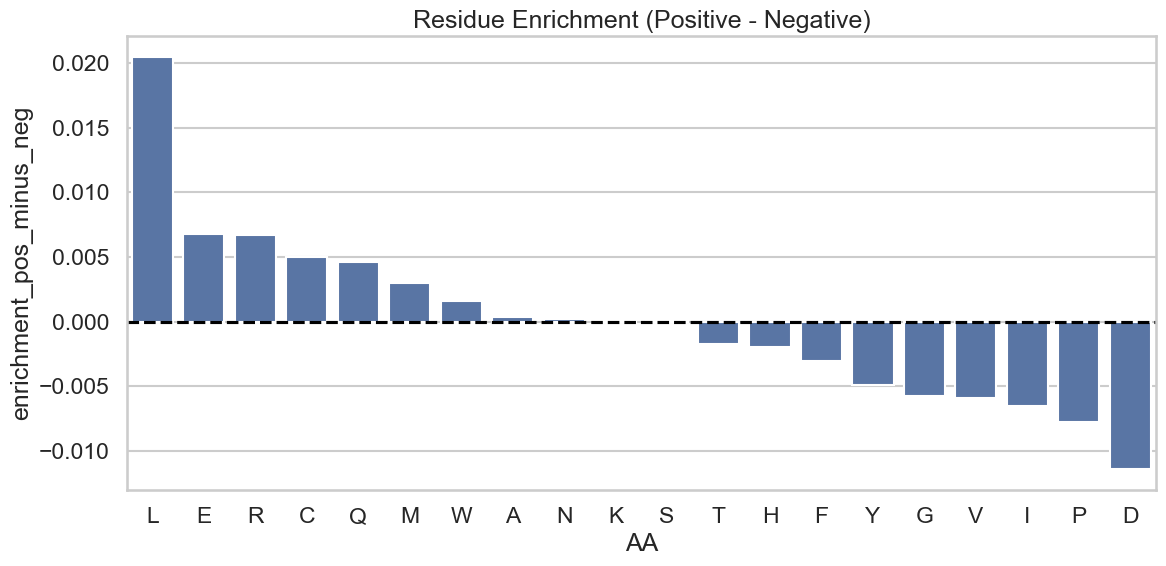

In [27]:
def residue_frequency_overall(seqs):
    total_counter = Counter()
    total_len = 0
    for seq in seqs:
        seq = str(seq).upper()
        total_counter.update(seq)
        total_len += len(seq)
    freq = {}
    for aa in AA_LIST:
        freq[aa] = total_counter.get(aa, 0) / total_len if total_len > 0 else 0.0
    return freq

pos_freq = residue_frequency_overall(test_df.loc[test_df["y_true"] == 1, "sequence"])
neg_freq = residue_frequency_overall(test_df.loc[test_df["y_true"] == 0, "sequence"])

enrich_df = pd.DataFrame({
    "AA": AA_LIST,
    "freq_neg": [neg_freq[a] for a in AA_LIST],
    "freq_pos": [pos_freq[a] for a in AA_LIST],
})
enrich_df["enrichment_pos_minus_neg"] = enrich_df["freq_pos"] - enrich_df["freq_neg"]
enrich_df = enrich_df.sort_values("enrichment_pos_minus_neg", ascending=False)

display(enrich_df)
enrich_df.to_csv(RESULTS_DIR / "residue_enrichment.csv", index=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=enrich_df, x="AA", y="enrichment_pos_minus_neg")
plt.axhline(0, color="black", linestyle="--")
plt.title("Residue Enrichment (Positive - Negative)")
plt.tight_layout()
plt.show()

## （6）SHAP

In [12]:
if not HAS_SHAP:
    raise ImportError("请先安装 shap: pip install shap")

def get_binary_shap_array(shap_values):
    """
    兼容不同 shap 版本输出：
    - list of arrays
    - 3D ndarray
    - 2D ndarray
    返回 shape = (n_samples, n_features)
    """
    if isinstance(shap_values, list):
        if len(shap_values) == 2:
            return np.array(shap_values[1])
        return np.array(shap_values[0])

    shap_values = np.array(shap_values)

    if shap_values.ndim == 3:
        # 可能是 (n_samples, n_features, n_classes)
        if shap_values.shape[-1] == 2:
            return shap_values[:, :, 1]
        # 也可能是 (n_classes, n_samples, n_features)
        if shap_values.shape[0] == 2:
            return shap_values[1]
    elif shap_values.ndim == 2:
        return shap_values

    raise ValueError(f"无法识别 shap_values 形状: {shap_values.shape}")

def compute_bagging_shap(model, X, max_estimators=20):
    """
    对 Bagging 中多棵树分别算 SHAP，再求平均。
    返回：
    - mean_shap: (n_samples, n_features)
    """
    if not hasattr(model, "estimators_"):
        raise ValueError("当前模型没有 estimators_，不适合此函数。")

    estimators = model.estimators_[:max_estimators]
    shap_list = []

    for i, est in enumerate(estimators):
        explainer = shap.TreeExplainer(est)
        sv = explainer.shap_values(X)
        sv = get_binary_shap_array(sv)
        shap_list.append(sv)

    mean_shap = np.mean(np.stack(shap_list, axis=0), axis=0)
    return mean_shap

In [13]:
# 为了加速，可以抽样
MAX_SHAP_SAMPLES = min(300, X_test.shape[0])
rng = np.random.RandomState(42)
sample_idx = rng.choice(np.arange(X_test.shape[0]), size=MAX_SHAP_SAMPLES, replace=False)

X_shap = X_test[sample_idx]
y_shap = y_test[sample_idx]
model_output='probability'
mean_shap_values = compute_bagging_shap(model, X_shap, max_estimators=min(20, len(model.estimators_)))

print("X_shap shape:", X_shap.shape)
print("SHAP shape  :", mean_shap_values.shape)

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. Consider retrying with the feature_perturbation='interventional' option. This check failed because for one of the samples the sum of the SHAP values was 3.919487, while the model output was 1.000000. If this difference is acceptable you can set check_additivity=False to disable this check.

In [ ]:
shap.summary_plot(
    mean_shap_values,
    features=X_shap,
    feature_names=feature_names,
    show=True
)

In [ ]:
shap.summary_plot(
    mean_shap_values,
    features=X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

In [ ]:
shap_imp = np.abs(mean_shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": shap_imp
}).sort_values("mean_abs_shap", ascending=False)

display(shap_df.head(20))
shap_df.to_csv(RESULTS_DIR / "shap_importance.csv", index=False)

topk = 20
plot_df = shap_df.head(topk).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["mean_abs_shap"])
plt.title(f"Top {topk} Mean |SHAP| Features")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

In [ ]:
# 映射回 test_df 原索引
sample_test_df = test_df.iloc[sample_idx].copy().reset_index(drop=True)

# 1) 正确预测的正样本
candidate_correct_pos = sample_test_df[(sample_test_df["y_true"] == 1) & (sample_test_df["y_pred"] == 1)]
if len(candidate_correct_pos) > 0:
    idx1 = candidate_correct_pos.index[0]
else:
    idx1 = 0

# 2) 错分样本
candidate_wrong = sample_test_df[sample_test_df["y_true"] != sample_test_df["y_pred"]]
if len(candidate_wrong) > 0:
    idx2 = candidate_wrong.index[0]
else:
    idx2 = min(1, len(sample_test_df) - 1)

for idx_case, title in [(idx1, "Correct Positive Example"), (idx2, "Misclassified Example")]:
    row = pd.DataFrame({
        "feature": feature_names,
        "value": X_shap[idx_case],
        "shap_value": mean_shap_values[idx_case],
        "abs_shap": np.abs(mean_shap_values[idx_case])
    }).sort_values("abs_shap", ascending=False)

    print("=" * 80)
    print(title)
    print(sample_test_df.loc[idx_case, ["sequence", "y_true", "y_pred"]])
    if "y_prob" in sample_test_df.columns:
        print("Pred prob:", sample_test_df.loc[idx_case, "y_prob"])
    display(row.head(15))

    plot_row = row.head(15).iloc[::-1]
    plt.figure(figsize=(10, 8))
    plt.barh(plot_row["feature"], plot_row["shap_value"])
    plt.title(title)
    plt.xlabel("SHAP value")
    plt.tight_layout()
    plt.show()

## （7）t-SNE

In [14]:
X_vis = X_test
y_vis = y_test

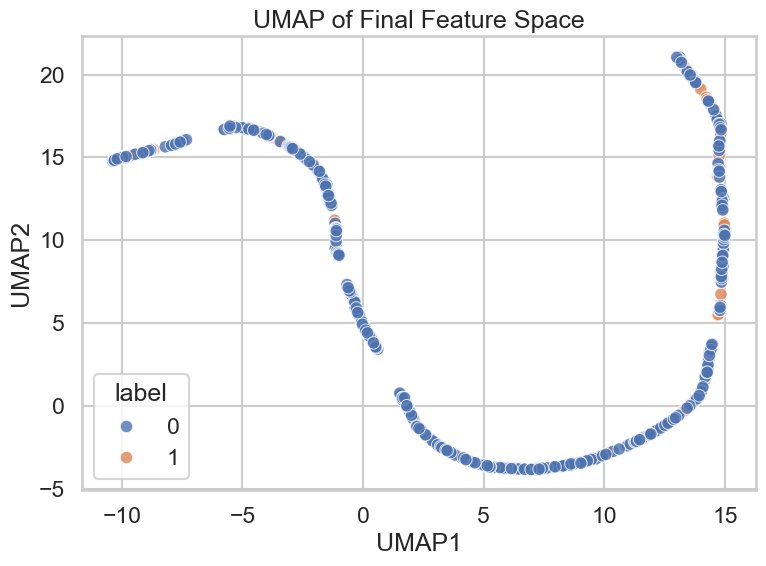

In [15]:
if HAS_UMAP:
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=42
    )
    X_umap = reducer.fit_transform(X_vis)

    umap_df = pd.DataFrame({
        "UMAP1": X_umap[:, 0],
        "UMAP2": X_umap[:, 1],
        "label": y_vis
    })

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="label", alpha=0.8)
    plt.title("UMAP of Final Feature Space")
    plt.tight_layout()
    plt.show()

    umap_df.to_csv(RESULTS_DIR / "umap_embedding.csv", index=False)
else:
    print("未安装 umap-learn，跳过。安装命令：pip install umap-learn")

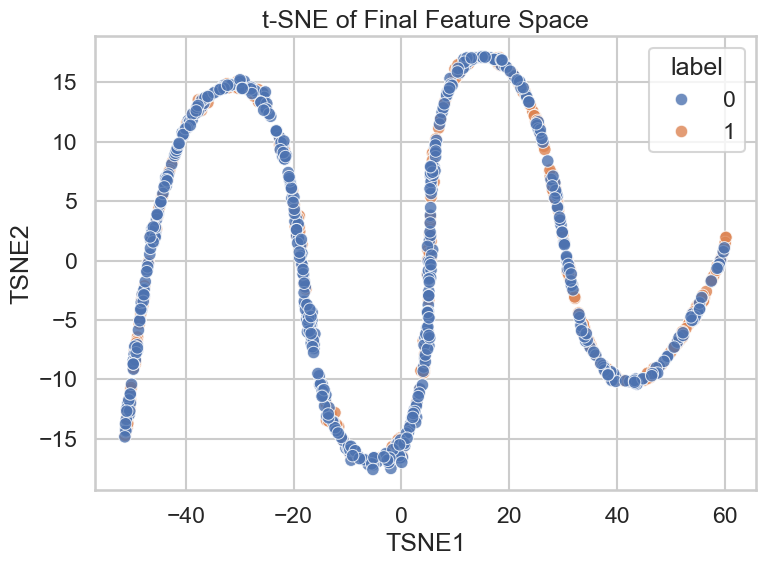

In [17]:
tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, X_vis.shape[0] // 10)),
    random_state=42,
    init="pca",
    learning_rate="auto"
)
X_tsne = tsne.fit_transform(X_vis)

tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "label": y_vis
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="label", alpha=0.8)
plt.title("t-SNE of Final Feature Space")
plt.tight_layout()
plt.show()

tsne_df.to_csv(RESULTS_DIR / "tsne_embedding.csv", index=False)